# パフォーマンスのチューニング: プルーニング、射影、コミットの粒度、キャッシュ

h5i-db はテーブルを、バージョン付きマニフェストの下の書き換え不能で時刻順の Parquet セグメント
として保存します。その配置が、何がクエリを速くし、何が静かに遅くするかを決めます。

1. **時間範囲のプルーニング。** マニフェストが各セグメントの時刻範囲を記録しているので、時刻の
   述語は I/O が始まる前にセグメントを丸ごと飛ばします。
2. **列の射影。** Parquet は列指向なので、触る列が少なければ読むバイトも少なくなります。
3. **コミットの粒度。** コミットのたびにマニフェストと最低1つのセグメントが書かれるので、
   小さなコミットが千件あれば、`compact()` するまで小さなファイルが千個できます。
4. **キャッシュ。** データベースを開いた直後の最初のクエリは、後続のクエリが払わずに済む
   セグメントのフッタとメタデータの読み取りを負担します。

この4つを約300万行のティックテーブルで測り、最後に共有のリサーチマシンで行儀よくするための
リソースのガード（`timeout`、`max_rows`、`memory_limit`）で締めます。

絶対値はマシン依存です。教訓は*比率*のほうです。

In [1]:
import time

import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_perf"), create=True)


def bench(fn, repeat=3):
    """Best-of-3 wall time - min filters out scheduler/GC noise."""
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return min(times)


timings_ms = {}  # collected for the chart at the end

## 1. データ

`cu.make_trades` の、3銘柄・10日ぶんのティックデータです。1行が1約定です。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 約定時刻、昇順 |
| `symbol` | `string` | 銘柄コード |
| `price` | `float64` | 約定価格 |
| `size` | `int64` | 約定株数 |
| `exchange` | `string` | 報告した取引所 |
| `side` | `string` | `B` は買い主導、`S` は売り主導 |

In [2]:
trades = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=10, trades_per_day=100_000, seed=42)
print(f"{trades.num_rows:,} rows x {trades.num_columns} columns")
trades.to_pandas().head()

2,945,940 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.011276+00:00,MSFT,198.02,1,NYSE,B
1,2026-06-01 13:30:00.014924+00:00,NVDA,349.04,1,BATS,S
2,2026-06-01 13:30:00.075562+00:00,MSFT,198.02,1,ARCA,B
3,2026-06-01 13:30:00.087663+00:00,AAPL,318.66,1,BATS,B
4,2026-06-01 13:30:00.106092+00:00,AAPL,318.59,1,NASDAQ,S


これを日ごとに追記します。h5i-db が期待するまとめ方、つまり公表イベントごとにコミット1件で、
行ごとでも1つの塊でもありません。

10件のコミットは1日あたりおよそ1セグメントを残します。それが以下の時刻の述語に、削るものを
与えます。

In [3]:
db.create_table("trades", trades.schema, time_column="ts", sort_key=["ts", "symbol"])

trades_df_ts = trades["ts"].to_pandas()
day_starts = trades_df_ts.dt.normalize().unique()
t0 = time.perf_counter()
for day in day_starts:
    day_end = day + pd.Timedelta(days=1)
    mask_lo = trades_df_ts.searchsorted(day)
    mask_hi = trades_df_ts.searchsorted(day_end)
    db.append("trades", trades.slice(mask_lo, mask_hi - mask_lo), note=f"day {day.date()}")
print(f"{len(trades):,} rows in {len(day_starts)} daily commits ({time.perf_counter() - t0:.1f}s)")

2,945,940 rows in 10 daily commits (0.9s)


## 2. 時間範囲のプルーニング: 10年ではなく1日を走査する

同じ形のクエリを2つの期間で。*全部*を実体化するのと、10日のうち1日ぶんとの比較です。

1日ぶんの走査が触るのは行のおよそ10%で、残り9つのセグメントはマニフェストのおかげで開かずに
飛ばせます。

2つの形に注意してください。`SELECT *` による素の実体化は、プルーニングの効きを最大限に見せ
ます。`GROUP BY` の集約は行あたりの計算が軽いので、実時間での改善は小さくなります。プルー
ニングが節約するのは I/O であって、ハッシュテーブルの仕事は削れないからです。

In [4]:
lo = int(pd.Timestamp("2026-06-05", tz="UTC").value // 1000)
hi = int(pd.Timestamp("2026-06-06", tz="UTC").value // 1000)
day_pred = f"ts >= to_timestamp_micros({lo}) AND ts < to_timestamp_micros({hi})"
agg = "SELECT symbol, count(*) AS n, vwap(price, size) AS vw FROM trades {} GROUP BY symbol"

timings_ms["SELECT * (10 days)"] = 1e3 * bench(lambda: db.sql("SELECT * FROM trades").to_arrow())
timings_ms["SELECT * (1 day)"] = 1e3 * bench(lambda: db.sql(f"SELECT * FROM trades WHERE {day_pred}").to_arrow())
timings_ms["agg (10 days)"] = 1e3 * bench(lambda: db.sql(agg.format("")).to_arrow())
timings_ms["agg (1 day)"] = 1e3 * bench(lambda: db.sql(agg.format(f"WHERE {day_pred}")).to_arrow())

print(f"materialize: {timings_ms['SELECT * (10 days)']:.0f} ms full -> "
      f"{timings_ms['SELECT * (1 day)']:.0f} ms one day "
      f"({timings_ms['SELECT * (10 days)'] / timings_ms['SELECT * (1 day)']:.1f}x)")
print(f"aggregate:   {timings_ms['agg (10 days)']:.1f} ms full -> "
      f"{timings_ms['agg (1 day)']:.1f} ms one day "
      f"({timings_ms['agg (10 days)'] / timings_ms['agg (1 day)']:.1f}x)")

materialize: 157 ms full -> 18 ms one day (8.7x)
aggregate:   17.6 ms full -> 12.6 ms one day (1.4x)


## 3. 射影: 列に名前を書く

6列のティックテーブルに対する `SELECT *` は、symbol、exchange、side の文字列をすべての演算子
に引きずり回します。

要る2列に名前を書けば、その Parquet の列チャンクだけを読みます。列指向の古典的な勝ち方で、
`SELECT *` が探索の道具にとどまる理由でもあります。定期ジョブには置かないでください。

In [5]:
timings_ms["SELECT ts, price"] = 1e3 * bench(lambda: db.sql("SELECT ts, price FROM trades").to_arrow())
print(f"SELECT *:         {timings_ms['SELECT * (10 days)']:.0f} ms")
print(f"SELECT ts, price: {timings_ms['SELECT ts, price']:.0f} ms "
      f"({timings_ms['SELECT * (10 days)'] / timings_ms['SELECT ts, price']:.1f}x)")

SELECT *:         157 ms
SELECT ts, price: 52 ms (3.0x)


## 4. コミットの粒度と、その解毒剤としての `compact()`

コミットはどれも永続化を伴います。マニフェストの書き込み、fsync、新しいセグメントファイル。

1日ぶんのティックを300回のマイクロバッチでコミットすると、取り込み時にその代金を300回払い、
*さらに*小さなセグメント300個を、以降のすべてのクエリが開くために残します。

`compact()` はそれを新しいバージョンとして1つのセグメントに書き直します。履歴は無傷で、古い
バージョンも読めるままです。

以下は1日ぶんのティック、およそ30万行を、両方のやり方で取り込んだものです。

In [6]:
day1 = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=1, trades_per_day=100_000, seed=43)

db.create_table("t_one", day1.schema, time_column="ts", sort_key=["ts", "symbol"])
t0 = time.perf_counter()
db.append("t_one", day1)
ingest_one = time.perf_counter() - t0

db.create_table("t_many", day1.schema, time_column="ts", sort_key=["ts", "symbol"])
n, k = len(day1), 300
chunk = n // k
t0 = time.perf_counter()
for i in range(k):
    db.append("t_many", day1.slice(i * chunk, chunk if i < k - 1 else n - (k - 1) * chunk))
ingest_many = time.perf_counter() - t0

print(f"ingest {n:,} rows: 1 commit {ingest_one:.2f}s vs {k} commits {ingest_many:.2f}s "
      f"({ingest_many / ingest_one:.0f}x slower)")

ingest 298,885 rows: 1 commit 0.10s vs 300 commits 3.42s (36x slower)


In [7]:
agg1 = "SELECT symbol, count(*) AS n, vwap(price, size) AS vw FROM {} GROUP BY symbol"
timings_ms["agg, 1 segment"] = 1e3 * bench(lambda: db.sql(agg1.format("t_one")).to_arrow())
timings_ms["agg, 300 segments"] = 1e3 * bench(lambda: db.sql(agg1.format("t_many")).to_arrow())

t0 = time.perf_counter()
c = db.compact("t_many")
compact_s = time.perf_counter() - t0
timings_ms["agg, compacted"] = 1e3 * bench(lambda: db.sql(agg1.format("t_many")).to_arrow())

print(f"aggregation: {timings_ms['agg, 300 segments']:.1f} ms on 300 segments, "
      f"{timings_ms['agg, 1 segment']:.1f} ms on 1 segment")
print(f"compact() took {compact_s:.2f}s -> segments_total={c['segments_total']}, "
      f"now {timings_ms['agg, compacted']:.1f} ms "
      f"({timings_ms['agg, 300 segments'] / timings_ms['agg, compacted']:.1f}x recovered)")

aggregation: 42.6 ms on 300 segments, 8.3 ms on 1 segment
compact() took 0.66s -> segments_total=1, now 7.5 ms (5.7x recovered)


## 5. コールドとウォーム: 最初のクエリがメタデータの代金を払う

データベースを開き直し、同じ集約を2回走らせます。1回目はセグメントのフッタを読んでメタデータの
キャッシュを作り、2回目以降はそれを飛ばします。

ローカルの NVMe なら差は控えめです。NFS やオブジェクトストレージ越しなら、長生きするリーダーを
残しておく価値を生む差になります。

In [8]:
db.close()
db = h5i_db.Database(cu.db_path("prod_perf"))  # fresh handle, cold caches

t0 = time.perf_counter()
db.sql(agg.format("")).to_arrow()
timings_ms["agg cold (1st run)"] = 1e3 * (time.perf_counter() - t0)
timings_ms["agg warm (best of 3)"] = 1e3 * bench(lambda: db.sql(agg.format("")).to_arrow())

print(f"cold: {timings_ms['agg cold (1st run)']:.1f} ms, warm: {timings_ms['agg warm (best of 3)']:.1f} ms "
      f"({timings_ms['agg cold (1st run)'] / timings_ms['agg warm (best of 3)']:.1f}x)")

cold: 21.7 ms, warm: 16.7 ms (1.3x)


## 6. 結果一覧

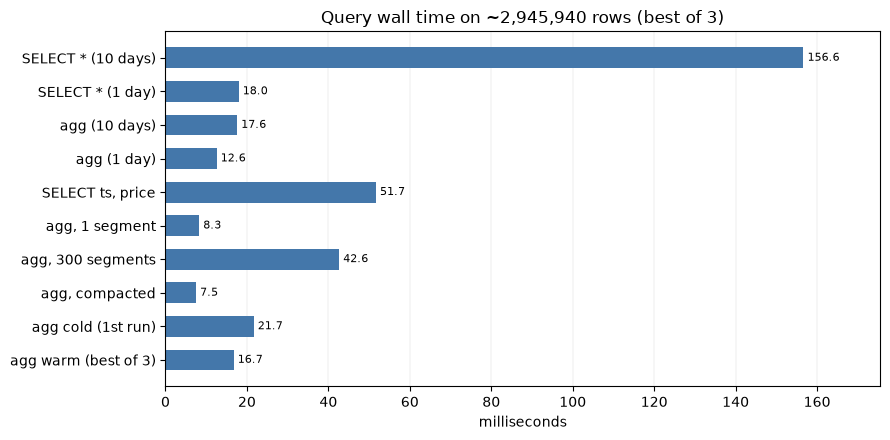

In [9]:
labels = list(timings_ms)[::-1]
values = [timings_ms[k] for k in labels]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels, values, height=0.62, color="#4477aa")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_title(f"Query wall time on ~{len(trades):,} rows (best of 3)")
ax.set_xlabel("milliseconds")
ax.margins(x=0.12)
ax.grid(axis="x", lw=0.3, alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()

## 7. リソースのガード: 本番の作法

共有のマシン、あるいは SQL を叩けるエージェントには、速く大きな音を立てて落ちるクエリが要り
ます。マシンを食い潰されては困るからです。

`db.sql` はどれも秒単位の `timeout=`、`max_rows=`、バイト単位の `memory_limit=` を受け取り
ます。違反すると型付きの例外、`TimeoutError` と `LimitError` が上がり、アラートを張れる
`.code` が付いてきます。`except Exception` で受けず、その型を捕まえてください。

In [10]:
try:
    db.sql("SELECT * FROM trades", max_rows=100_000)
except h5i_db.LimitError as e:
    print(f"max_rows    -> LimitError   code={e.code} hint={e.hint}")

try:
    db.sql("SELECT * FROM trades", timeout=0.001)
except h5i_db.TimeoutError as e:
    print(f"timeout     -> TimeoutError code={e.code}")

try:
    db.sql(agg.format(""), memory_limit=100_000)  # 100 kB budget: not enough
except h5i_db.LimitError as e:
    print(f"memory_limit-> LimitError   code={e.code}")

max_rows    -> LimitError   code=limit_exceeded hint=None


timeout     -> TimeoutError code=timeout
memory_limit-> LimitError   code=limit_exceeded


## 8. エンジンの代金: 正直な数字

設計ドキュメントによれば、h5i-db の汎用の走査経路には**同じ Parquet ファイルを素の DataFusion
で引く場合に対しておよそ20%のオーバーヘッド**があります。バージョンの解決、マニフェストの
記帳、そしてプルーニングの仕掛けの代金です。

その代わりにタイムトラベル、アトミックなコミット、時系列の演算子が手に入ります。1回きりの
一括走査のレイテンシがどうしても critical なら、テーブルのセグメントファイルに別の Parquet
リーダーを向けることはいつでもできます。

本番の数字を実際に動かすチューニングのレバーを、手を伸ばすべき順に挙げます。

1. 自然な時間の窓があるクエリには、必ず時刻の述語を置く
2. 列に名前を書く
3. append はまとめる（フィードのバッチごとにコミット1件）。取り込みが不規則だったあとは
   `compact()` をかける
4. リーダーのプロセスを生かしておき、キャッシュを温かく保つ
5. ユーザーやエージェントが生成するものには `timeout`／`max_rows`／`memory_limit` を設定する

## まとめ

- 時刻の述語がこのシステムでいちばん安上がりな高速化です。マニフェストが I/O の前にセグメントを
  丸ごと削り、実体化する走査ではここでおよそ8倍でした。集約の伸びが小さいのは、コストが I/O
  ではなくハッシュの仕事だからです。
- 幅のあるティックテーブルでは射影が効きます。300万行に対して、2列は `SELECT *` のおよそ3倍
  速く走りました。
- コミットの粒度は本物のつまみです。300回のマイクロコミットは、まとめたコミット1件に比べて
  取り込みをおよそ60倍、クエリを3〜4倍遅くしました。`compact()` は1秒かからずクエリ時間を
  取り戻します。
- コールドで開く代金はプロセスごとに1回だけなので、長生きするリーダーがそれを償却します。
- ガード（`timeout`、`max_rows`、`memory_limit`）はリソースの暴走を、型付きで捕まえられる
  エラーに変えます。共有マシンとエージェントのアクセスには必須です。

In [11]:
db.close()